# Audio Classification with Scikit-Learn Pipeline (SVC)
This notebook refactors the audio classification task to use `Pipeline` and `ColumnTransformer` with `SVC(kernel='poly')` to match and verify the results from the original notebook.

In [6]:
import numpy as np
import pandas as pd
import os
import sys
import librosa
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, 
    f1_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)
import matplotlib.pyplot as plt

# Add path for custom utils
if './dataset/cats_dogs_dataset' not in sys.path:
    sys.path.append('./dataset/cats_dogs_dataset')
import myutils

print(f"CUDA available: {torch.cuda.is_available()}")

CUDA available: True


## 1. Data Preparation
We merge the split categories into unified training and testing sets using numeric targets (0 for cat, 1 for dog).

In [7]:
df_split = pd.read_csv('dataset/cats_dogs_dataset/train_test_split.csv', index_col=0)
df_split = df_split.dropna()

audio_dir = 'dataset/cats_dogs_dataset/cats_dogs/'

def prepare_data(df, columns):
    data_list = []
    for col in columns:
        label = 0 if 'cat' in col else 1
        for filename in df[col]:
            data_list.append({
                'path': os.path.join(audio_dir, filename),
                'label': label
            })
    return pd.DataFrame(data_list)

train_data = prepare_data(df_split, ['train_cat', 'train_dog'])
test_data = prepare_data(df_split, ['test_cat', 'test_dog'])

print(f"Training samples: {len(train_data)}")
print(f"Testing samples: {len(test_data)}")
train_data.head()

Training samples: 98
Testing samples: 98


,path,label
0,dataset/cats_dogs_dataset/cats_dogs/cat_99.wav,0
1,dataset/cats_dogs_dataset/cats_dogs/cat_54.wav,0
2,dataset/cats_dogs_dataset/cats_dogs/cat_34.wav,0
3,dataset/cats_dogs_dataset/cats_dogs/cat_132.wav,0
4,dataset/cats_dogs_dataset/cats_dogs/cat_124.wav,0


## 2. Feature Extraction
We extract audio features using the `myutils` helper.

In [8]:
def extract_features_to_df(df):
    features_list = []
    for idx, row in df.iterrows():
        try:
            feat = myutils.feature_extraction(row['path'])
            
            # Expand MFCC arrays into separate columns
            mean_mfcc = feat.pop('mean_mfcc')
            std_mfcc = feat.pop('std_mfcc')
            for i, v in enumerate(mean_mfcc):
                feat[f"mfcc_mean_{i+1}"] = v
            for i, v in enumerate(std_mfcc):
                feat[f"mfcc_std_{i+1}"] = v
                
            feat['label'] = row['label']
            features_list.append(feat)
        except Exception as e:
            print(f"Error processing {row['path']}: {e}")
            
    return pd.DataFrame(features_list)

print("Extracting training features...")
X_train_full = extract_features_to_df(train_data)
print("Extracting testing features...")
X_test_full = extract_features_to_df(test_data)

y_train = X_train_full['label']
X_train = X_train_full.drop(columns=['label'])
y_test = X_test_full['label']
X_test = X_test_full.drop(columns=['label'])

Extracting training features...
Extracting testing features...


## 3. Pipeline & ColumnTransformer
We use `ColumnTransformer` to scale numerical features and `Pipeline` to chain it with an `SVC` classifier.

In [9]:
# Identify all numerical columns for scaling
numeric_features = X_train.columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features)
    ])

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC(kernel='poly', random_state=42))
])

print("Fitting pipeline...")
pipeline.fit(X_train, y_train)
print("Pipeline training complete.")

Fitting pipeline...
Pipeline training complete.


## 4. Evaluation
Evaluating the model performance on the test set.

         EVALUATION RESULTS (Pipeline)
Accuracy  : 0.8776
Precision : 0.9111
Recall    : 0.8367
F1 Score  : 0.8723

Classification Report:
              precision    recall  f1-score   support

         cat       0.85      0.92      0.88        49
         dog       0.91      0.84      0.87        49

    accuracy                           0.88        98
   macro avg       0.88      0.88      0.88        98
weighted avg       0.88      0.88      0.88        98



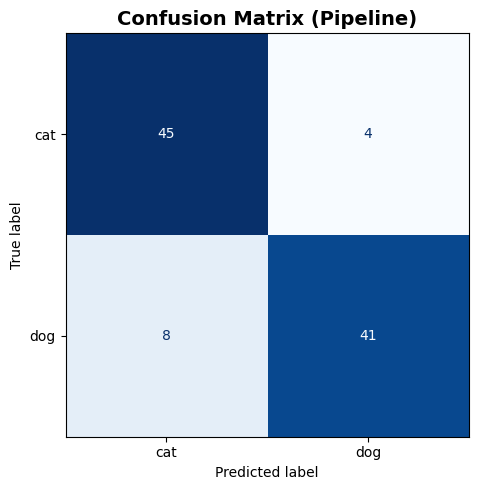

In [10]:
y_pred = pipeline.predict(X_test)
print("=" * 40)
print("         EVALUATION RESULTS (Pipeline)")
print("=" * 40)
print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision : {precision_score(y_test, y_pred):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score  : {f1_score(y_test, y_pred):.4f}")
print("=" * 40)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['cat', 'dog']))

cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['cat', 'dog'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix (Pipeline)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()